Name: Christopher A. Lee\
Date: 04/07/2026\
Prof: Dr. Azarnoosh\
Course: Machine Learning for Data Analysis - ENBC 321

In [1]:
# Libraries
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestCentroid

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Import Data
df = pd.read_csv('patients_data.csv')

# Preprocess Data
X1 = df[['Age', 'Insulin_Level']]
X2 = df[['Age', 'BMI']]

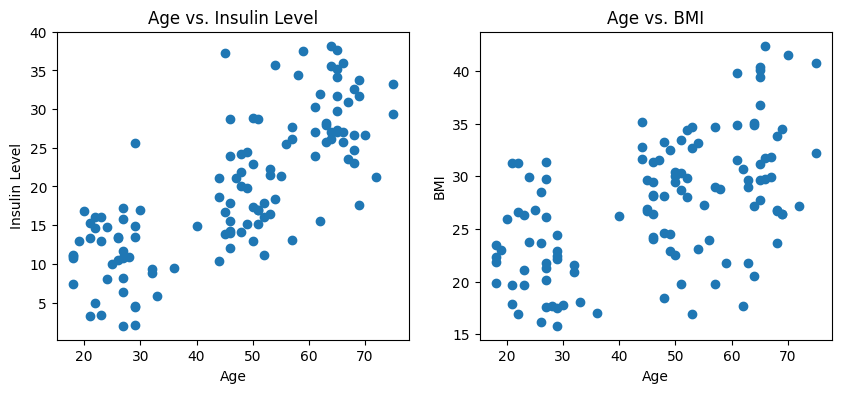

In [3]:
# Data Visualization
fig1, ax1 = plt.subplots(1, 2, figsize=(10,4))

ax1[0].scatter(X1['Age'], X1['Insulin_Level'])
ax1[0].set_title("Age vs. Insulin Level")
ax1[0].set_xlabel("Age")
ax1[0].set_ylabel("Insulin Level")
ax1[1].scatter(X2['Age'], X2['BMI'])
ax1[1].set_title("Age vs. BMI")
ax1[1].set_xlabel("Age")
ax1[1].set_ylabel("BMI")
plt.show()

In [4]:
# Normalization
X1_scaler, X2_scaler = StandardScaler(), StandardScaler()

X1_scaled, X2_scaled = X1_scaler.fit_transform(X1), X2_scaler.fit_transform(X2)

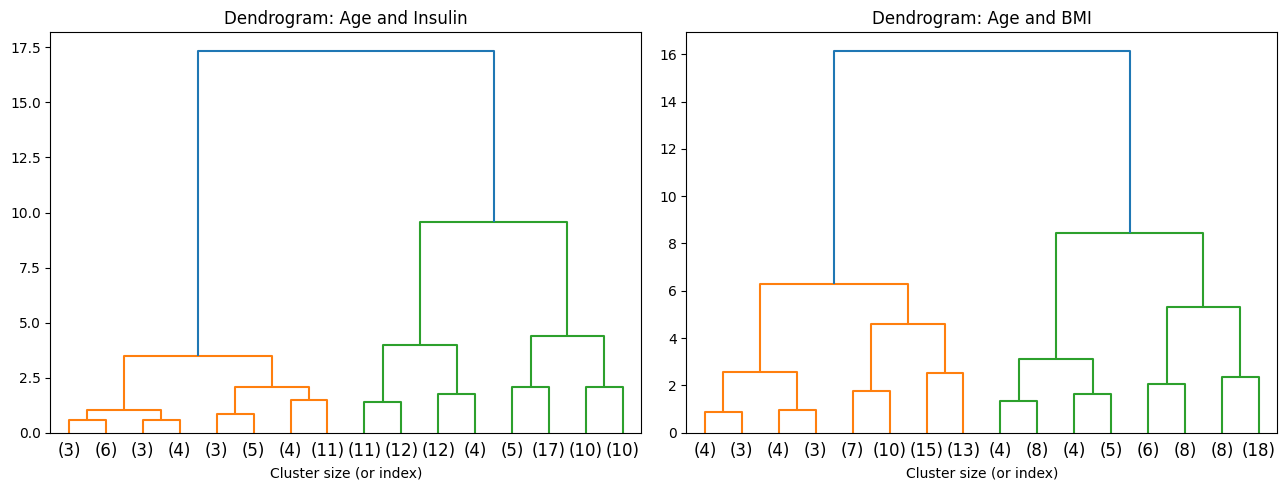

In [5]:
# Dendrogram Plots
Z1 = linkage(X1_scaled, method='ward', metric='euclidean')
Z2 = linkage(X2_scaled, method='ward', metric='euclidean')

fig2, ax2 = plt.subplots(1, 2, figsize=(13,5))

dendrogram(Z1, truncate_mode='level', p=3, ax=ax2[0])
ax2[0].set_title('Dendrogram: Age and Insulin') 
ax2[0].set_xlabel('Cluster size (or index)')
dendrogram(Z2, truncate_mode='level', p=3, ax=ax2[1])
ax2[1].set_title('Dendrogram: Age and BMI') 
ax2[1].set_xlabel('Cluster size (or index)')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'BMI (Scaled)')

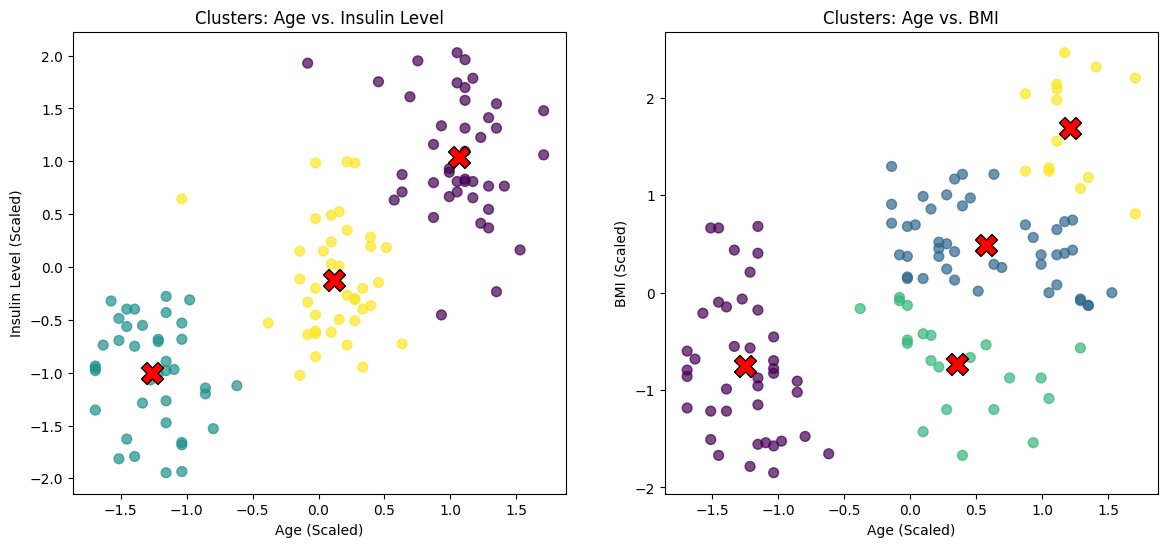

In [6]:
# Optimal k value
# If you cut at 7.5 for the first dendrogram, you will get 3. All of the other cuts seemed unreasonable
# since they were so close together. For the second dendrogram, if you cut at 6, you will get 4. I could
# have gone further to cut lower or higher but brach lengths at that point seemed really out of place.
# I didn't go upwards because the orange brach on the very left from the height of 3 to 6 seemed long
# enought to be important, hence the cut at height 6.
k1, k2 = 3, 4

# Agglomerative Clustering
model_ac1 = AgglomerativeClustering(n_clusters=k1, linkage='ward', compute_distances=True, metric='euclidean').fit(X1_scaled)
model_ac2 = AgglomerativeClustering(n_clusters=k2, linkage='ward', compute_distances=True, metric='euclidean').fit(X2_scaled)

# Centroids
clf1 = NearestCentroid().fit(X1_scaled, model_ac1.labels_)
clf2 = NearestCentroid().fit(X2_scaled, model_ac2.labels_)

# Clustered 2D plots
fig3, ax3 = plt.subplots(1, 2, figsize=(14, 6)) 
ax3[0].scatter(X1_scaled[:, 0], X1_scaled[:, 1], c=model_ac1.labels_, cmap='viridis', s=50, alpha=0.7)
ax3[0].scatter(clf1.centroids_[:, 0], clf1.centroids_[:, 1], c='red', marker='X', s=250, label='Cluster Centers', edgecolors='black')
ax3[0].set_title("Clusters: Age vs. Insulin Level")
ax3[0].set_xlabel("Age (Scaled)")
ax3[0].set_ylabel("Insulin Level (Scaled)")

ax3[1].scatter(X2_scaled[:, 0], X2_scaled[:, 1], c=model_ac2.labels_, cmap='viridis', s=50, alpha=0.7)
ax3[1].scatter(clf2.centroids_[:, 0], clf2.centroids_[:, 1], c='red', marker='X', s=250, label='Cluster Centers', edgecolors='black')
ax3[1].set_title("Clusters: Age vs. BMI")
ax3[1].set_xlabel("Age (Scaled)")
ax3[1].set_ylabel("BMI (Scaled)")


In [7]:
print("1. They differ because agglomerative clustering is a bottom up approach building a hierarchy \nby mergining the closest pairs while k-means is top down using a centroid based method.")
print("2. Hierarchial clustering might be preferable due to its ability of revealing nested relationships \nand biological subtypes that k-means might not be able to find.")
print("3. As the number of features increases, the hierarchial clustering becomes very computationally \nexpensive due to its O(n^2) complexity. In addition to this, as the number of features is\n increased, the distance metrics like Euclidean distance become less meaningful.")

1. They differ because agglomerative clustering is a bottom up approach building a hierarchy 
by mergining the closest pairs while k-means is top down using a centroid based method.
2. Hierarchial clustering might be preferable due to its ability of revealing nested relationships 
and biological subtypes that k-means might not be able to find.
3. As the number of features increases, the hierarchial clustering becomes very computationally 
expensive due to its O(n^2) complexity. In addition to this, as the number of features is
 increased, the distance metrics like Euclidean distance become less meaningful.
